In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SedimentacaoSimulador:
    """
    Simulador para o problema de sedimentação de uma esfera.
    Resolve a EDO adimensional usando Runge-Kutta de 4ª ordem (RK4).
    """
    
    def __init__(self, stokes_num, reynolds_num):
        self.St = stokes_num
        self.Re = reynolds_num

    def f_derivada(self, t, v):
        """
        Define a função f(t, v) = dv/dt da forma adimensional.
        Equação: dv/dt = (1/St) * (1 - v - (3/8)*Re*v^2) [cite: 71, 137]
        """
        return (1 / self.St) * (1 - v - (3/8) * self.Re * (v**2))

    def resolver_rk4(self, h, t_final, v0=0.0):
        """
        Implementação clássica do algoritmo Runge-Kutta de 4ª ordem[cite: 130, 131].
        """
        tempos = np.arange(0, t_final + h, h)
        velocidades = np.zeros(len(tempos))
        velocidades[0] = v0
        
        for i in range(len(tempos) - 1):
            t = tempos[i]
            v = velocidades[i]
            
            k1 = self.f_derivada(t, v)
            k2 = self.f_derivada(t + h/2, v + (h/2) * k1)
            k3 = self.f_derivada(t + h/2, v + (h/2) * k2)
            k4 = self.f_derivada(t + h, v + h * k3)
            
            velocidades[i+1] = v + (h/6) * (k1 + 2*k2 + 2*k3 + k4) * h
            
        return tempos, velocidades

    def solucao_analitica_stokes(self, tempos):
        """Solução exata para Re -> 0[cite: 49]."""
        return 1 - np.exp(-tempos / self.St)

    def solucao_analitica_ricatti(self, tempos):
        """Solução exata (Ricatti) para Re > 0[cite: 79, 80]."""
        # Constantes auxiliares conforme o artigo
        v_star = (-1 + np.sqrt(1 + 1.5 * self.Re)) / (0.75 * self.Re)
        Q = (3 / (8 * self.St)) * self.Re
        P = -(3 / (4 * self.St)) * self.Re * v_star - (1 / self.St)
        
        # v(t) = v* + [Q/P + (-1/v* - Q/P) * exp(-Pt)]^-1
        termo_exp = ((-1/v_star) - (Q/P)) * np.exp(-P * tempos)
        return v_star + 1.0 / ( (Q/P) + termo_exp )


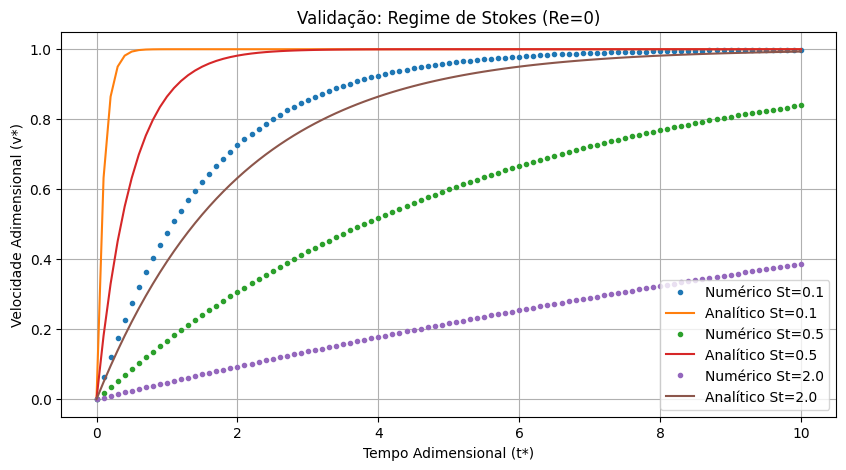

In [ ]:
# --- EXECUÇÃO DAS ANÁLISES DO PPC ---

# 1. Comparação Re -> 0 para diferentes Stokes
plt.figure(figsize=(10, 5))
st_values = [0.1, 0.5, 2.0]
sim_stokes = SedimentacaoSimulador(stokes_num=0.5, reynolds_num=0.0)
for st in st_values:
    sim_stokes.St = st
    t, v_num = sim_stokes.resolver_rk4(h=0.1, t_final=10)
    v_ana = sim_stokes.solucao_analitica_stokes(t)
    plt.plot(t, v_num, 'o', label=f'Numérico St={st}', markersize=3)
    plt.plot(t, v_ana, '-', label=f'Analítico St={st}')

plt.title("Validação: Regime de Stokes (Re=0)")
plt.xlabel("Tempo Adimensional (t*)")
plt.ylabel("Velocidade Adimensional (v*)")
plt.legend()
plt.grid(True)
plt.show()



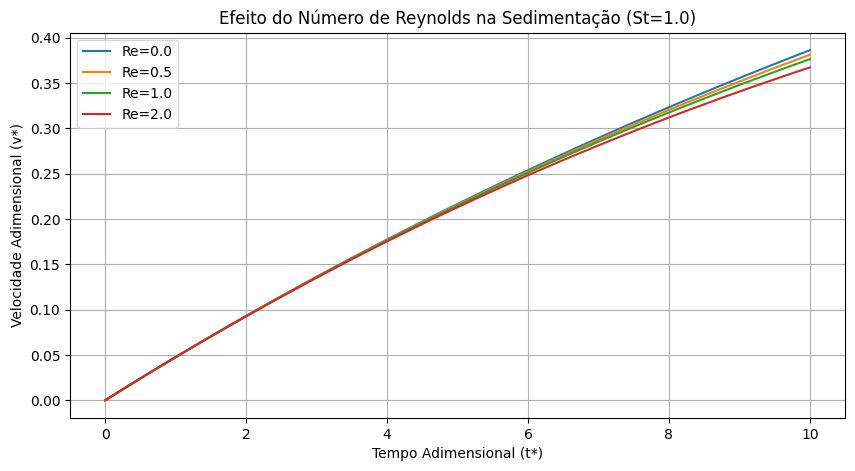

In [4]:
# 2. Efeito do Reynolds (Inércia) [cite: 156, 158]
plt.figure(figsize=(10, 5))
re_values = [0.0, 0.5, 1.0, 2.0]
sim_re = SedimentacaoSimulador(stokes_num=1.0, reynolds_num=0.0)
for re in re_values:
    sim_re.Re = re
    t, v_num = sim_re.resolver_rk4(h=0.05, t_final=10)
    plt.plot(t, v_num, label=f'Re={re}')

plt.title("Efeito do Número de Reynolds na Sedimentação (St=1.0)")
plt.xlabel("Tempo Adimensional (t*)")
plt.ylabel("Velocidade Adimensional (v*)")
plt.legend()
plt.grid(True)
plt.show()